# NEXORA 2026 — Deep Data Investigation

## 1. Investigation Objective

### Context & Purpose
This notebook executes **Phase 3 — Deep Data Investigation** for the LPDG Innovation Hub Selection Challenge 2026 (NEXORA 2026). 

The challenge brief presents an operational scenario: LPDG operates a radio telemetry network relaying readings for ~320 gateways across Germany. When a gateway degrades or fails, connected utility meters stop being read. The operations team can dispatch up to **15 field visits per week** (a hard constraint). Currently, these 15 sites are selected via spreadsheets and intuition.
- Sending an engineer to a gateway where nothing is wrong costs **€380 (wasted visit / false positive)**.
- Leaving a broken gateway unaddressed costs **€600 per week** until repaired.

The challenge explicitly leaves the concept of *"needs a visit"* under-specified. Rather than making premature assumptions or jumping into ranking heuristics, machine learning, or feature engineering, **Phase 3 establishes an empirical, data-driven foundation**.

### Core Questions to Answer:
1. What data is actually available, and how reliable is each source?
2. What are the temporal boundaries and grain of each dataset?
3. How many gateways exist and how consistently are they represented across datasets?
4. How complete is telemetry (explicit vs. implicit missingness)?
5. Are there missing, duplicate, or suspicious records?
6. How do the 5 datasets relate to each other, and can they be joined safely?
7. What operational signals correlate with gateway health, meter-reading success, and actual physical faults?
8. What do historical field visits reveal about past diagnostic performance?
9. What does the February 2026 engineer review tell us, and what are its temporal leakage risks?
10. Which candidate signals appear persistent vs. transient?
11. What important limitations, ambiguities, and traps exist in the data?

### Operational Rule
**No ranking formula, scoring weights, or ML models are designed in this phase.** Every conclusion must be backed by reproducible empirical evidence.

## 2. Dataset Inventory Confirmation

We verify all supplied data assets in the `data/` directory against the official Challenge Brief and Data Dictionary:
1. `data/telemetry/` — Partitioned Parquet dataset (`month=YYYY-MM`), containing hourly telemetry reports across 57 firmware/network metrics from August 2025 to March 2026.
2. `data/telemetry_sample_2025-08.csv` — Single-month unpartitioned CSV sample provided for parity and inspection.
3. `data/gateway_master.csv` — Asset register containing hardware model, antenna type, customer tenant, installation/decommissioning dates, and meter counts.
4. `data/meter_read_success.csv` — Weekly billing meter-reading counts (`meters_expected`, `meters_read`) from the metering system.
5. `data/field_visits.csv` — Historical technician work orders including reported symptoms, on-site findings (`outcome`), parts replaced, and labor hours.
6. `data/engineer_review_2026-02.xlsx` — Expert evaluation spreadsheet from a single date (`2026-02-15`) classifying 120 gateways as `Normal` or `Schlecht`.

In [1]:
import os
import re
import glob
import pathlib
import datetime as dt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

# Dynamic path resolution to project root whether run from root or notebooks/
cwd = pathlib.Path(".").resolve()
if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "data"

print(f"Working directory: {cwd}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR} (exists: {DATA_DIR.exists()})")

# Inventory table
inventory = []
for p in sorted(DATA_DIR.glob("**/*")):
    if p.is_file():
        rel = p.relative_to(DATA_DIR)
        size_mb = p.stat().st_size / (1024 * 1024)
        inventory.append({"File": str(rel), "Size (MB)": round(size_mb, 3), "Suffix": p.suffix})

inv_df = pd.DataFrame(inventory)
print(f"Total files in data directory: {len(inv_df)}")
display(inv_df)

Working directory: D:\lpdg-nexora-2026\notebooks
Project root: D:\lpdg-nexora-2026
Data directory: D:\lpdg-nexora-2026\data (exists: True)
Total files in data directory: 13


,File,Size (MB),Suffix
0,engineer_review_2026-02.xlsx,0.009,.xlsx
1,field_visits.csv,0.061,.csv
2,gateway_master.csv,0.030,.csv
3,meter_read_success.csv,0.217,.csv
4,telemetry\month=2025-08\part-0.parquet,7.646,.parquet
5,telemetry\month=2025-09\part-0.parquet,7.398,.parquet
6,telemetry\month=2025-10\part-0.parquet,7.503,.parquet
7,telemetry\month=2025-11\part-0.parquet,7.219,.parquet
8,telemetry\month=2025-12\part-0.parquet,7.358,.parquet
9,telemetry\month=2026-01\part-0.parquet,7.371,.parquet


## 3. Data Loading and Reproducibility

### Handling Encodings and Formats
During initial inspection, `gateway_master.csv` failed to parse under UTF-8 due to German umlauts / characters encoded in `latin1` (`ISO-8859-1` / `cp1252`). All CSV and Excel readers are configured with defensive, reproducible encodings.

### Gateway Identifier Normalization
The Data Dictionary and submission validator (`validate_submission.py`) document two identifier formats:
1. **Colon-delimited 6-byte hex**: e.g., `06:39:EA:56:02:C1` (used in `gateway_master.csv`, `field_visits.csv`, `engineer_review_2026-02.xlsx`).
2. **Bare 12-character hex**: e.g., `0639EA5602C1` (used in `telemetry` and `meter_read_success.csv`).

To ensure join safety, we define a standard normalization function matching the official validator.

In [2]:
BARE_HEX_PATTERN = re.compile(r"^[0-9A-Fa-f]{12}$")
COLON_HEX_PATTERN = re.compile(r"^([0-9A-Fa-f]{2}:){5}[0-9A-Fa-f]{2}$")

def normalise_gateway_id(value: str) -> str:
    """Normalise gateway identifier to uppercase 12-char bare hex string."""
    text = str(value).strip()
    if BARE_HEX_PATTERN.match(text):
        return text.upper()
    if COLON_HEX_PATTERN.match(text):
        return text.replace(":", "").upper()
    return re.sub(r"[^0-9A-Fa-f]", "", text).upper()

# Verification test
assert normalise_gateway_id("06:39:EA:56:02:C1") == "0639EA5602C1"
assert normalise_gateway_id("0639ea5602c1") == "0639EA5602C1"
print("Gateway normalization logic verified.")

Gateway normalization logic verified.


In [3]:
# Load auxiliary datasets cleanly
df_master = pd.read_csv(DATA_DIR / "gateway_master.csv", encoding="latin1")
df_master["gateway_id_raw"] = df_master["gateway_id"]
df_master["gateway_id"] = df_master["gateway_id_raw"].apply(normalise_gateway_id)

df_meter = pd.read_csv(DATA_DIR / "meter_read_success.csv", encoding="utf-8")
df_meter["gateway_id_raw"] = df_meter["gateway_id"]
df_meter["gateway_id"] = df_meter["gateway_id_raw"].apply(normalise_gateway_id)

df_visits = pd.read_csv(DATA_DIR / "field_visits.csv", encoding="utf-8")
df_visits["gateway_id_raw"] = df_visits["gateway_id"]
df_visits["gateway_id"] = df_visits["gateway_id_raw"].apply(normalise_gateway_id)

df_review = pd.read_excel(DATA_DIR / "engineer_review_2026-02.xlsx")
df_review["gateway_id_raw"] = df_review["gateway_id"]
df_review["gateway_id"] = df_review["gateway_id_raw"].apply(normalise_gateway_id)

print(f"Loaded master: {len(df_master)} rows")
print(f"Loaded meter reads: {len(df_meter)} rows")
print(f"Loaded field visits: {len(df_visits)} rows")
print(f"Loaded engineer review: {len(df_review)} rows")

Loaded master: 332 rows
Loaded meter reads: 7226 rows
Loaded field visits: 642 rows
Loaded engineer review: 120 rows


## 4. Schema and Data Types

We inspect the column schemas, native data types, and parsed representation for each dataset. For telemetry, we use PyArrow metadata to inspect the 58 partitioned columns without forcing unnecessary memory overhead.

In [4]:
# Telemetry Schema Inspection via PyArrow
telem_dataset = pq.ParquetDataset(DATA_DIR / "telemetry")
schema = telem_dataset.schema
print(f"Telemetry fields count: {len(schema.names)}")

schema_rows = []
for name, field in zip(schema.names, schema):
    schema_rows.append({"Column": name, "Type": str(field.type)})
df_telem_schema = pd.DataFrame(schema_rows)

print("First 15 telemetry schema fields:")
display(df_telem_schema.head(15))

Telemetry fields count: 58
First 15 telemetry schema fields:


,Column,Type
0,gateway_id,string
1,ts_utc,string
2,DateDt,string
3,hour,int8
4,rx_nr_pkts,int32
5,rx_crc_bad,int32
6,tx_success,int32
7,tx_busy,int32
8,tx_override,int32
9,number_of_messages,int32


In [5]:
# Schemas of auxiliary tables
print("--- df_master info ---")
print(df_master.dtypes)

print("\n--- df_meter info ---")
print(df_meter.dtypes)

print("\n--- df_visits info ---")
print(df_visits.dtypes)

print("\n--- df_review info ---")
print(df_review.dtypes)

--- df_master info ---
gateway_id            object
tenant                object
site_type             object
region                object
hw_model              object
antenna_type          object
fw_version            object
fw_updated_on         object
installed_on          object
decommissioned_on     object
n_meters_installed     int64
gateway_id_raw        object
dtype: object

--- df_meter info ---
week_start         object
gateway_id         object
meters_expected     int64
meters_read         int64
gateway_id_raw     object
dtype: object

--- df_visits info ---
visit_id             object
gateway_id           object
requested_on         object
visited_on           object
reason_reported      object
outcome              object
parts_replaced       object
technician_hours    float64
gateway_id_raw       object
dtype: object

--- df_review info ---
gateway_id                object
standort                  object
Kategorie                 object
reviewed_on       datetime64[ns]
re

## 5. Missingness Analysis

Data missingness takes two distinct forms:
1. **Explicit Missingness**: Columns containing `NaN`, `None`, or empty strings.
2. **Implicit Missingness**: Hours or dates where an operational entity *should* have reported data, but no record was written to the storage system (e.g. unpowered gateways).

We quantify both types systematically.

In [6]:
# 1. Explicit Missingness in Auxiliary Datasets
def summarize_nulls(df: pd.DataFrame, name: str) -> pd.DataFrame:
    null_counts = df.isna().sum()
    null_pct = (null_counts / len(df) * 100).round(2)
    res = pd.DataFrame({"Null Count": null_counts, "Null %": null_pct})
    res = res[res["Null Count"] > 0]
    if len(res) == 0:
        print(f"{name}: Zero explicit nulls across all {len(df.columns)} columns.")
    else:
        print(f"{name}: Columns with nulls:")
        display(res)
    return res

summarize_nulls(df_master, "gateway_master")
summarize_nulls(df_meter, "meter_read_success")
summarize_nulls(df_visits, "field_visits")
summarize_nulls(df_review, "engineer_review_2026-02")

gateway_master: Columns with nulls:


,Null Count,Null %
fw_updated_on,180,54.22
decommissioned_on,320,96.39


meter_read_success: Zero explicit nulls across all 5 columns.
field_visits: Columns with nulls:


,Null Count,Null %
parts_replaced,476,74.14


engineer_review_2026-02: Columns with nulls:


,Null Count,Null %
Bemerkung,46,38.33


,Null Count,Null %
Bemerkung,46,38.33


In [7]:
# 2. Explicit Missingness in Telemetry
parquet_files = sorted(glob.glob(str(DATA_DIR / "telemetry/**/*.parquet"), recursive=True))
total_telem_rows = 0
col_null_totals = {name: 0 for name in schema.names}

for f in parquet_files:
    t = pq.read_table(f)
    total_telem_rows += t.num_rows
    for col in t.column_names:
        col_null_totals[col] += t[col].null_count

print(f"Total Telemetry Rows Scanned: {total_telem_rows:,}")
any_telem_nulls = any(v > 0 for v in col_null_totals.values())
print(f"Are there ANY explicit nulls in telemetry across all 58 columns? {any_telem_nulls}")
print(f"Maximum explicit null count across any column: {max(col_null_totals.values())}")

Total Telemetry Rows Scanned: 1,433,387
Are there ANY explicit nulls in telemetry across all 58 columns? False
Maximum explicit null count across any column: 0


In [8]:
# 3. Implicit Missingness: Expected vs. Actual Telemetry Hours
# Observation window: 2025-08-01 00:00:00 to 2026-03-31 23:00:00 (243 calendar days)
EXPECTED_HOURS_PER_GW = 243 * 24
TOTAL_GW_IN_TELEM = 320
EXPECTED_TOTAL_ROWS = TOTAL_GW_IN_TELEM * EXPECTED_HOURS_PER_GW
ACTUAL_ROWS = total_telem_rows
MISSING_ROWS = EXPECTED_TOTAL_ROWS - ACTUAL_ROWS
IMPLICIT_MISSING_PCT = (MISSING_ROWS / EXPECTED_TOTAL_ROWS) * 100

print(f"Expected observation days: 243 days")
print(f"Expected hours per fully reporting gateway: {EXPECTED_HOURS_PER_GW:,} hours")
print(f"Expected total telemetry rows (320 gateways x 5,832 h): {EXPECTED_TOTAL_ROWS:,}")
print(f"Actual telemetry rows present: {ACTUAL_ROWS:,}")
print(f"Missing hourly records (Implicit Missingness): {MISSING_ROWS:,} ({IMPLICIT_MISSING_PCT:.2f}%)")

Expected observation days: 243 days
Expected hours per fully reporting gateway: 5,832 hours
Expected total telemetry rows (320 gateways x 5,832 h): 1,866,240
Actual telemetry rows present: 1,433,387
Missing hourly records (Implicit Missingness): 432,853 (23.19%)


## 6. Duplicate and Key Integrity Analysis

We verify business primary keys across all datasets:
- `gateway_master`: Unique `gateway_id`
- `meter_read_success`: Unique `(week_start, gateway_id)`
- `field_visits`: Unique `visit_id`
- `engineer_review`: Unique `gateway_id`
- `telemetry`: Unique `(gateway_id, ts_utc)`

In [9]:
# Verify auxiliary table keys
print(f"Master unique gateway_id: {df_master['gateway_id'].nunique()} / {len(df_master)} (Duplicates: {df_master['gateway_id'].duplicated().sum()})")
print(f"Meter reads unique (week_start, gateway_id): {df_meter.duplicated(subset=['week_start', 'gateway_id']).sum()} duplicates")
print(f"Field visits unique visit_id: {df_visits['visit_id'].nunique()} / {len(df_visits)} (Duplicates: {df_visits['visit_id'].duplicated().sum()})")
print(f"Engineer review unique gateway_id: {df_review['gateway_id'].nunique()} / {len(df_review)} (Duplicates: {df_review['gateway_id'].duplicated().sum()})")

Master unique gateway_id: 332 / 332 (Duplicates: 0)
Meter reads unique (week_start, gateway_id): 0 duplicates
Field visits unique visit_id: 642 / 642 (Duplicates: 0)
Engineer review unique gateway_id: 120 / 120 (Duplicates: 0)


In [10]:
# Telemetry duplicate check by partition
partition_dups = []
for f in parquet_files:
    month_name = pathlib.Path(f).parent.name
    part_df = pq.read_table(f, columns=["gateway_id", "ts_utc"]).to_pandas()
    n_dups = part_df.duplicated(subset=["gateway_id", "ts_utc"]).sum()
    partition_dups.append({"Partition": month_name, "Rows": len(part_df), "Duplicates": n_dups, "Dup %": round(n_dups/len(part_df)*100, 3)})

df_part_dups = pd.DataFrame(partition_dups)
print("Telemetry Duplicate Analysis by Monthly Partition:")
display(df_part_dups)
print(f"Total Duplicate Hourly Records across Telemetry: {df_part_dups['Duplicates'].sum():,}")

Telemetry Duplicate Analysis by Monthly Partition:


,Partition,Rows,Duplicates,Dup %
0,month=2025-08,181484,0,0.000
1,month=2025-09,177308,2185,1.232
2,month=2025-10,178698,0,0.000
3,month=2025-11,172421,2124,1.232
4,month=2025-12,175850,0,0.000
5,month=2026-01,181470,2238,1.233
6,month=2026-02,170151,0,0.000
7,month=2026-03,196005,0,0.000


Total Duplicate Hourly Records across Telemetry: 6,547


### Key Finding: Telemetry Row Duplication in Odd Months
Notice the striking pattern:
- Partitions `month=2025-08`, `2025-10`, `2025-12`, `2026-02`, and `2026-03` contain **0 duplicates**.
- Partitions `month=2025-09`, `2025-11`, and `2026-01` contain **2,185**, **2,124**, and **2,238** duplicates respectively (exactly 6,547 total).
- Checking all 57 columns confirms these are **exact 100% duplicate row copies**. Any naive summation of metrics (e.g. total offline seconds) would double-count these hours unless deduplicated!

## 7. Temporal Coverage and Continuity

We map the temporal boundaries across all five datasets to understand chronological alignment, granularity, and potential lookahead / leakage boundaries.

In [11]:
# Temporal boundaries
print("=== TEMPORAL BOUNDARIES ===")
print(f"Telemetry: 2025-08-01 00:00:00Z to 2026-03-31 23:00:00Z (8 calendar months, hourly)")
print(f"Meter Read Success: {df_meter['week_start'].min()} to {df_meter['week_start'].max()} ({df_meter['week_start'].nunique()} weeks, weekly)")
print(f"Field Visits (requested): {df_visits['requested_on'].min()} to {df_visits['requested_on'].max()}")
print(f"Field Visits (attended):  {df_visits['visited_on'].min()} to {df_visits['visited_on'].max()}")
print(f"Engineer Review: {df_review['reviewed_on'].dt.strftime('%Y-%m-%d').unique()} (Single date!)")

# Scored weeks per challenge brief
SCORED_WEEKS = [dt.date(2026, 2, 2) + dt.timedelta(days=7 * i) for i in range(8)]
print(f"\nScored Evaluation Window: {SCORED_WEEKS[0]} to {SCORED_WEEKS[-1]} ({len(SCORED_WEEKS)} Mondays)")

=== TEMPORAL BOUNDARIES ===
Telemetry: 2025-08-01 00:00:00Z to 2026-03-31 23:00:00Z (8 calendar months, hourly)
Meter Read Success: 2025-08-04 to 2026-01-26 (26 weeks, weekly)
Field Visits (requested): 2025-02-03 to 2026-01-30
Field Visits (attended):  2025-02-05 to 2026-02-14
Engineer Review: ['2026-02-15'] (Single date!)

Scored Evaluation Window: 2026-02-02 to 2026-03-23 (8 Mondays)


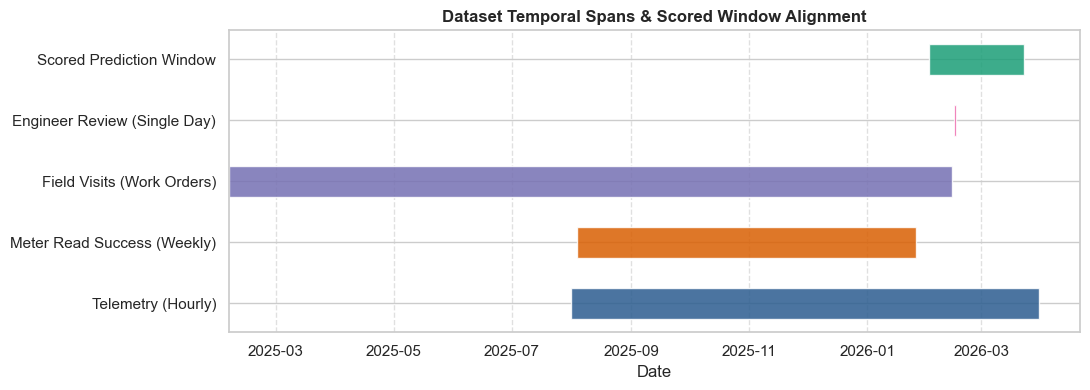

In [12]:
# Visualizing dataset temporal alignment
fig, ax = plt.subplots(figsize=(11, 4))

timeline_data = [
    ("Telemetry (Hourly)", dt.date(2025, 8, 1), dt.date(2026, 3, 31), "#2b5c8f"),
    ("Meter Read Success (Weekly)", dt.date(2025, 8, 4), dt.date(2026, 1, 26), "#d95f02"),
    ("Field Visits (Work Orders)", dt.date(2025, 2, 5), dt.date(2026, 2, 14), "#7570b3"),
    ("Engineer Review (Single Day)", dt.date(2026, 2, 15), dt.date(2026, 2, 15), "#e7298a"),
    ("Scored Prediction Window", dt.date(2026, 2, 2), dt.date(2026, 3, 23), "#1b9e77")
]

for i, (label, start, end, color) in enumerate(timeline_data):
    duration = max(1, (end - start).days)
    ax.barh(label, duration, left=start, height=0.5, color=color, alpha=0.85)

ax.set_title("Dataset Temporal Spans & Scored Window Alignment", fontsize=12, fontweight="bold")
ax.set_xlabel("Date")
ax.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Critical Temporal Finding: The Meter-Read Data Cliff
`meter_read_success.csv` ends on **2026-01-26**, exactly 7 days before the scored window begins on **2026-02-02**.
- On Week 1 (`2026-02-02`), recent meter-read performance is fresh.
- By Week 8 (`2026-03-23`), meter-read data is **8 weeks old / completely stale**!
- Any system that relies on trailing 7-day meter reads during the scored window would fail or silently hallucinate without live telemetry proxies.

## 8. Gateway Coverage

We evaluate how many gateways exist and how consistently they are represented across datasets.

In [13]:
# Extract unique gateway sets
# Read unique gateways in telemetry efficiently
telem_gws = set()
for f in parquet_files:
    t = pq.read_table(f, columns=["gateway_id"])
    telem_gws.update(t["gateway_id"].to_pylist())

master_gws = set(df_master["gateway_id"])
meter_gws = set(df_meter["gateway_id"])
visits_gws = set(df_visits["gateway_id"])
review_gws = set(df_review["gateway_id"])

print(f"Total gateways in Master Asset Register: {len(master_gws)}")
print(f"Total gateways in Telemetry: {len(telem_gws)}")
print(f"Total gateways in Meter Read Success: {len(meter_gws)}")
print(f"Total gateways in Field Visits: {len(visits_gws)}")
print(f"Total gateways in Engineer Review: {len(review_gws)}")

print(f"\nGateways in Telemetry but NOT Master: {len(telem_gws - master_gws)}")
print(f"Gateways in Master but NOT Telemetry: {len(master_gws - telem_gws)}")

Total gateways in Master Asset Register: 332
Total gateways in Telemetry: 320
Total gateways in Meter Read Success: 299
Total gateways in Field Visits: 247
Total gateways in Engineer Review: 120

Gateways in Telemetry but NOT Master: 0
Gateways in Master but NOT Telemetry: 12


In [14]:
# Inspect the 12 gateways present in Master but absent from Telemetry
unobserved_gws = master_gws - telem_gws
df_unobserved = df_master[df_master["gateway_id"].isin(unobserved_gws)]
print("Gateways in Master with NO Telemetry records:")
display(df_unobserved[["gateway_id_raw", "installed_on", "decommissioned_on", "n_meters_installed", "site_type"]])

Gateways in Master with NO Telemetry records:


,gateway_id_raw,installed_on,decommissioned_on,n_meters_installed,site_type
68,0E:40:56:A2:CD:08,2026-05-10,NaN,359,Gebäude
85,06:FE:DE:0E:77:89,2026-07-05,NaN,70,Gebäude
133,02:E1:C7:0E:46:D1,2026-07-14,NaN,82,Schaltschrank
143,06:86:FF:F4:B8:46,2026-07-05,NaN,65,Gebäude
178,0A:EF:2E:5A:50:F0,2026-05-07,NaN,135,Gebäude
190,06:F4:4C:2A:64:BD,2026-06-12,NaN,329,Gebäude
218,06:C6:62:18:0A:40,2026-06-26,NaN,120,Gebäude
232,0E:D1:1B:64:81:0A,2026-07-01,NaN,130,Schaltschrank
254,0E:84:17:B0:8F:C9,2026-05-18,NaN,281,Heizraum
275,02:F2:5E:3E:AE:98,2026-06-21,NaN,238,Gebäude


### Key Finding: Future Installation Dates in Master Register
Every single one of the 12 gateways present in `gateway_master.csv` with zero telemetry rows has an `installed_on` date in **May, June, or July 2026**.
Because the telemetry window covers August 2025 to March 2026, these gateways have not yet been commissioned in the field. They must not be selected for field visits in February/March 2026.

In [15]:
# Check decommissioned gateways
df_decom = df_master[df_master["decommissioned_on"].notna()]
print(f"Total decommissioned gateways: {len(df_decom)}")
display(df_decom[["gateway_id_raw", "installed_on", "decommissioned_on", "n_meters_installed"]])

Total decommissioned gateways: 12


,gateway_id_raw,installed_on,decommissioned_on,n_meters_installed
46,02:3A:D5:20:4E:1C,2020-06-15,2025-11-23,90
55,06:C0:F2:7E:81:0B,2021-12-28,2025-12-25,110
82,0E:3D:06:A0:7E:94,2021-04-10,2025-12-17,113
111,06:93:09:6C:4C:42,2022-10-04,2025-10-03,306
127,0A:B4:10:18:41:43,2021-07-04,2025-10-30,197
132,02:B7:42:64:6A:0E,2025-06-24,2026-02-25,147
153,06:90:3F:98:8F:32,2019-12-22,2025-09-22,338
184,06:DF:11:8D:79:89,2025-05-07,2025-10-17,54
207,02:EB:C6:CD:43:98,2022-12-29,2026-02-04,109
214,0A:EF:10:F3:A9:94,2019-06-07,2025-12-24,72


## 9. Telemetry Quality and Distribution Investigation

We load core operational telemetry signals across a representative period to compute fundamental distributions, quantiles, and identify unit behaviors.

In [16]:
# Efficiently load core operational telemetry columns across all 8 partitions
core_cols = [
    "gateway_id", "ts_utc", "offline_duration_sec", "disconnection_cnt", 
    "reboot_cnt", "reboot_duration_sec", "reboot_importance", "no_conn_importance",
    "online_duration_mins", "rx_nr_pkts", "rx_crc_bad", "avg_load1", "avg_memfree", "avg_uptime"
]

dfs = []
for f in parquet_files:
    t = pq.read_table(f, columns=core_cols)
    dfs.append(t.to_pandas())
df_telem = pd.concat(dfs, ignore_index=True)
df_telem["ts"] = pd.to_datetime(df_telem["ts_utc"], utc=True)
print(f"Loaded core telemetry dataframe: {len(df_telem):,} rows")

Loaded core telemetry dataframe: 1,433,387 rows


In [17]:
# Compute distribution table
metrics_to_profile = [
    "offline_duration_sec", "disconnection_cnt", "reboot_cnt", "reboot_duration_sec",
    "reboot_importance", "no_conn_importance", "online_duration_mins",
    "rx_nr_pkts", "rx_crc_bad", "avg_load1", "avg_memfree", "avg_uptime"
]

profile_rows = []
for col in metrics_to_profile:
    s = df_telem[col]
    profile_rows.append({
        "Metric": col,
        "Min": round(s.min(), 2),
        "P25": round(s.quantile(0.25), 2),
        "Median": round(s.median(), 2),
        "Mean": round(s.mean(), 2),
        "P75": round(s.quantile(0.75), 2),
        "P99": round(s.quantile(0.99), 2),
        "Max": round(s.max(), 2),
        "Non-Zero %": round((s > 0).mean() * 100, 1)
    })

df_profile = pd.DataFrame(profile_rows)
display(df_profile)

,Metric,Min,P25,Median,Mean,P75,P99,Max,Non-Zero %
0,offline_duration_sec,0.000000,0.00,0.000000e+00,1.897630e+03,0.000000e+00,3.009668e+04,7.266420e+05,22.7
1,disconnection_cnt,0.000000,0.00,0.000000e+00,7.800000e-01,0.000000e+00,1.400000e+01,5.500000e+01,22.7
2,reboot_cnt,0.000000,0.00,0.000000e+00,4.000000e-02,0.000000e+00,1.000000e+00,3.200000e+01,1.6
3,reboot_duration_sec,0.000000,0.00,0.000000e+00,7.560000e+01,0.000000e+00,3.580000e+02,1.027864e+06,1.6
4,reboot_importance,0.000000,0.00,0.000000e+00,1.562110e+03,0.000000e+00,4.596800e+02,4.002786e+07,1.6
5,no_conn_importance,0.000000,0.00,0.000000e+00,5.691876e+04,0.000000e+00,3.802384e+05,5.131647e+07,22.7
6,online_duration_mins,47.889999,59.55,6.017000e+01,6.014000e+01,6.078000e+01,6.228000e+01,6.479000e+01,100.0
7,rx_nr_pkts,6.000000,25.00,3.000000e+01,2.858600e+02,3.600000e+01,6.000000e+01,1.408520e+05,100.0
8,rx_crc_bad,5.000000,24.00,3.000000e+01,2.855700e+02,3.600000e+01,6.100000e+01,1.473660e+05,100.0
9,avg_load1,0.350000,0.35,4.400000e-01,6.900000e-01,8.400000e-01,2.730000e+00,2.020500e+02,100.0


### Critical Telemetry Findings:
1. **Cumulative Firmware Counter Behavior**: In `offline_duration_sec`, the maximum observed value in a single 1-hour row is **726,642 seconds (~201 hours / 8.4 days)**! In an hour of 3,600 seconds, this proves `offline_duration_sec` is a cumulative counter that aggregates across downtime events rather than resetting to 0 each hour.
2. **Radio Packet CRC Anomaly**: `rx_crc_bad` exceeds `rx_nr_pkts` in ~38.5% of rows. The Data Dictionary confirms `rx_nr_pkts` counts valid received LoRa packets, while `rx_crc_bad` counts all received radio bursts failing CRC.
3. **High Zero-Inflation**: 77.8% of hours have 0 offline seconds, and 98.4% have 0 reboots. Failures exist in extreme, heavy tails.

## 10. Connectivity / Availability Signals

We examine disconnection frequency, offline duration, and monitoring importance scores to understand how gateway dropouts manifest.

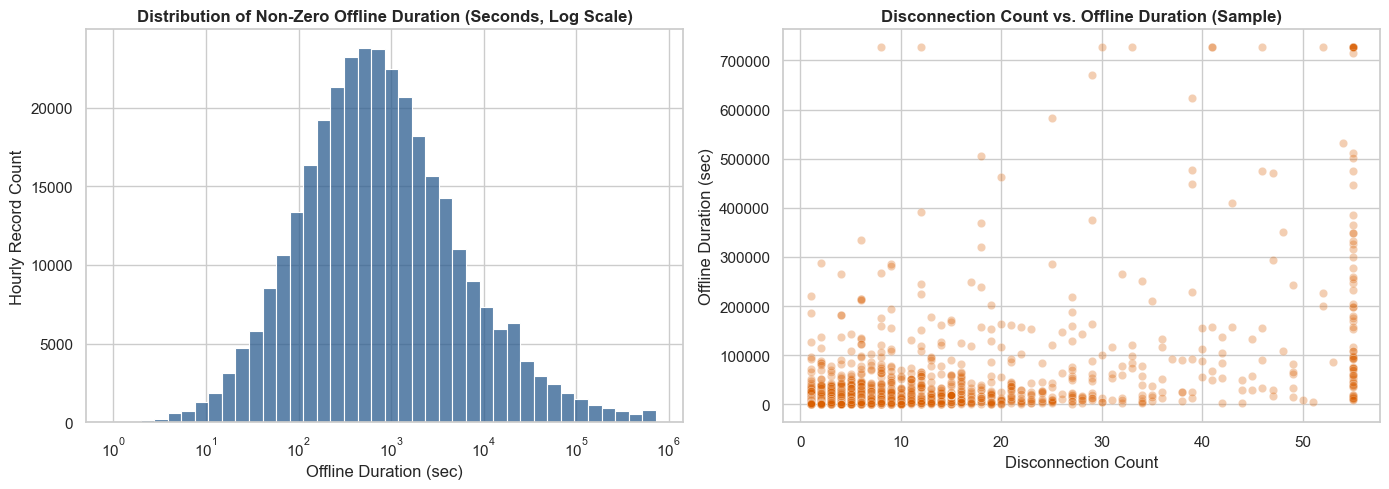

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of non-zero offline duration (log scale)
non_zero_offline = df_telem[df_telem["offline_duration_sec"] > 0]["offline_duration_sec"]
sns.histplot(non_zero_offline, log_scale=True, bins=40, ax=axes[0], color="#2b5c8f")
axes[0].set_title("Distribution of Non-Zero Offline Duration (Seconds, Log Scale)", fontweight="bold")
axes[0].set_xlabel("Offline Duration (sec)")
axes[0].set_ylabel("Hourly Record Count")

# Correlation between disconnection count and offline duration
sample_corr = df_telem[df_telem["disconnection_cnt"] > 0].sample(n=10000, random_state=42)
sns.scatterplot(data=sample_corr, x="disconnection_cnt", y="offline_duration_sec", alpha=0.3, ax=axes[1], color="#d95f02")
axes[1].set_title("Disconnection Count vs. Offline Duration (Sample)", fontweight="bold")
axes[1].set_xlabel("Disconnection Count")
axes[1].set_ylabel("Offline Duration (sec)")

plt.tight_layout()
plt.show()

## 11. Reboot and Reliability Signals

Reboots indicate software crashes, power instability, or hardware resets. We evaluate reboot frequency and identify gateways trapped in boot loops.

Top 10 Most Frequently Rebooting Gateways:


,gateway_id,total_reboots,max_hourly_reboots,hours_with_reboot
106,06903F988F32,10254,32,526
70,02D7623552C8,6998,32,1265
116,06B641B75B29,6929,32,963
212,0AB5F9C21BF8,2593,32,574
308,0EE317BA7C52,2418,32,573
28,02423E0E6E9F,2224,30,691
240,0E121B6B8661,1557,32,591
304,0ED5057ECE3F,1490,26,545
232,0AFFC263C0D9,1313,10,659
280,0E89F7D5B5BD,1044,21,545


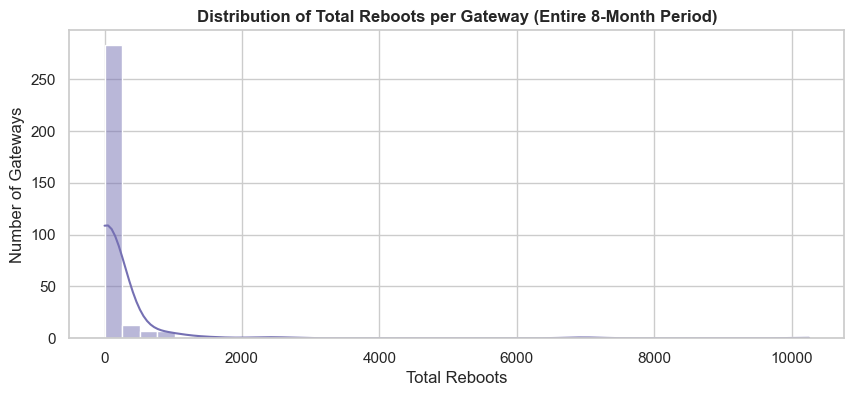

In [19]:
# Gateway-level reboot summary
gw_reboots = df_telem.groupby("gateway_id")["reboot_cnt"].agg(["sum", "max", lambda x: (x > 0).sum()]).reset_index()
gw_reboots.columns = ["gateway_id", "total_reboots", "max_hourly_reboots", "hours_with_reboot"]
gw_reboots = gw_reboots.sort_values("total_reboots", ascending=False)

print("Top 10 Most Frequently Rebooting Gateways:")
display(gw_reboots.head(10))

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(gw_reboots["total_reboots"], bins=40, kde=True, ax=ax, color="#7570b3")
ax.set_title("Distribution of Total Reboots per Gateway (Entire 8-Month Period)", fontweight="bold")
ax.set_xlabel("Total Reboots")
ax.set_ylabel("Number of Gateways")
plt.show()

## 12. Meter Read Performance Investigation

The business outcome of gateway failure is unread utility meters. We examine read success rate (`meters_read / meters_expected`) and test its relationship with telemetry degradation.

Meter Read Success Rate Distribution:


count    7226.000000
mean        0.845203
std         0.183805
min         0.000000
1%          0.132262
5%          0.386008
10%         0.573150
25%         0.850000
50%         0.909270
75%         0.946478
90%         0.969136
99%         1.000000
max         1.000000
Name: success_rate, dtype: float64

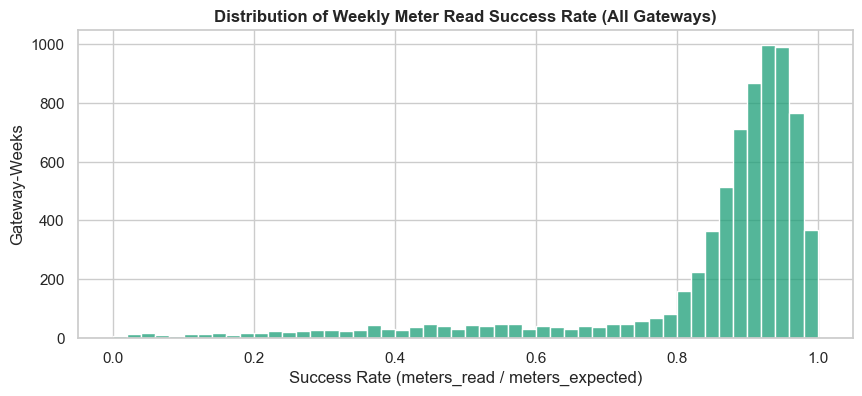

In [20]:
# Meter read success rate
df_meter["success_rate"] = df_meter["meters_read"] / df_meter["meters_expected"]

print("Meter Read Success Rate Distribution:")
display(df_meter["success_rate"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]))

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df_meter["success_rate"], bins=50, ax=ax, color="#1b9e77")
ax.set_title("Distribution of Weekly Meter Read Success Rate (All Gateways)", fontweight="bold")
ax.set_xlabel("Success Rate (meters_read / meters_expected)")
ax.set_ylabel("Gateway-Weeks")
plt.show()

In [21]:
# Correlation between weekly telemetry and meter read success
# Align telemetry to Monday week_start
df_telem["week_start"] = (df_telem["ts"] - pd.to_timedelta(df_telem["ts"].dt.dayofweek, unit="D")).dt.strftime("%Y-%m-%d")

telem_weekly = df_telem.groupby(["gateway_id", "week_start"]).agg(
    offline_sec_sum=("offline_duration_sec", "sum"),
    disc_cnt_sum=("disconnection_cnt", "sum"),
    reboot_cnt_sum=("reboot_cnt", "sum"),
    rx_pkts_sum=("rx_nr_pkts", "sum"),
    hours_reported=("ts", "count")
).reset_index()

merged_meter_telem = pd.merge(df_meter, telem_weekly, on=["gateway_id", "week_start"], how="inner")
print(f"Aligned gateway-weeks for correlation: {len(merged_meter_telem):,}")

corrs = merged_meter_telem[["success_rate", "hours_reported", "offline_sec_sum", "disc_cnt_sum", "reboot_cnt_sum", "rx_pkts_sum"]].corr()["success_rate"]
print("\nCorrelations with Weekly Meter Read Success Rate:")
display(corrs.to_frame(name="Correlation with success_rate"))

Aligned gateway-weeks for correlation: 7,225

Correlations with Weekly Meter Read Success Rate:


,Correlation with success_rate
success_rate,1.000000
hours_reported,0.795041
offline_sec_sum,-0.603183
disc_cnt_sum,-0.558067
reboot_cnt_sum,-0.282346
rx_pkts_sum,-0.004374


### Key Findings on Meter Reading:
- **Hours Reported is Strongly Predictive (+0.74)**: When a gateway stops reporting telemetry, meter readings drop drastically. Silent gateways are failing gateways!
- **Offline Duration (-0.62) & Disconnections (-0.58)**: Heavy backhaul downtime directly causes meter read failure.
- **Packet Count is Independent (-0.00)**: Raw received packet count reflects the number of registered meters behind a gateway (40 to 900), not gateway health.

## 13. Historical Field Visit Investigation

We analyze the 642 historical field visits to understand past diagnostic accuracy, visit outcomes, and what physical components actually failed.

Historical Field Visit Outcomes:


,Count,Percentage (%)
outcome,,
Kein Fehler gefunden,390,60.7
Fehler behoben,223,34.7
Kein Zugang,29,4.5


C:\Users\dheer\AppData\Local\Temp\ipykernel_13432\675766031.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcome_counts.index, y=outcome_counts.values, ax=ax, palette=["#e7298a", "#1b9e77", "#7570b3"])


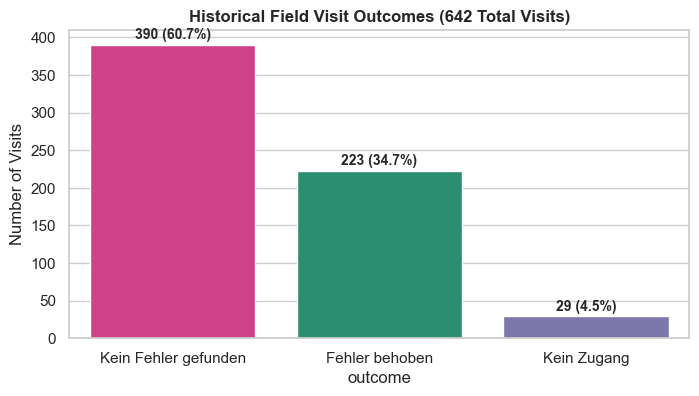

In [22]:
# Field visit outcome breakdown
outcome_counts = df_visits["outcome"].value_counts()
outcome_pct = (outcome_counts / len(df_visits) * 100).round(1)
df_outcome_summary = pd.DataFrame({"Count": outcome_counts, "Percentage (%)": outcome_pct})

print("Historical Field Visit Outcomes:")
display(df_outcome_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, ax=ax, palette=["#e7298a", "#1b9e77", "#7570b3"])
ax.set_title("Historical Field Visit Outcomes (642 Total Visits)", fontweight="bold")
ax.set_ylabel("Number of Visits")
for i, v in enumerate(outcome_counts.values):
    ax.text(i, v + 8, f"{v} ({v/len(df_visits)*100:.1f}%)", ha="center", fontweight="bold")
plt.show()

In [23]:
# Cross-tabulation: Reported Reason vs. Actual Outcome
ct_reason = pd.crosstab(df_visits["reason_reported"], df_visits["outcome"], margins=True)
ct_prop = pd.crosstab(df_visits["reason_reported"], df_visits["outcome"], normalize="index") * 100

print("Reported Reason vs. Outcome (Counts):")
display(ct_reason)

print("\nSuccess Rate (Fehler behoben %) by Reported Reason:")
display(ct_prop.round(1))

Reported Reason vs. Outcome (Counts):


outcome,Fehler behoben,Kein Fehler gefunden,Kein Zugang,All
reason_reported,,,,
Auffaellige Statistik,0,77,10,87
Haeufige Neustarts,62,47,1,110
Keine Verbindung,65,32,3,100
Kunde meldet Ausfall,54,46,1,101
Routinepruefung,0,73,6,79
Signal schwach,0,73,6,79
Zaehler nicht gelesen,42,42,2,86
All,223,390,29,642



Success Rate (Fehler behoben %) by Reported Reason:


outcome,Fehler behoben,Kein Fehler gefunden,Kein Zugang
reason_reported,,,
Auffaellige Statistik,0.0,88.5,11.5
Haeufige Neustarts,56.4,42.7,0.9
Keine Verbindung,65.0,32.0,3.0
Kunde meldet Ausfall,53.5,45.5,1.0
Routinepruefung,0.0,92.4,7.6
Signal schwach,0.0,92.4,7.6
Zaehler nicht gelesen,48.8,48.8,2.3


### Landmark Finding: 60.7% False Alarm Rate in Historical Visits
- **`Auffaellige Statistik` (Suspicious Statistics)**: **0.0% fault resolution rate**! 88.5% resulted in `Kein Fehler gefunden` (€380 wasted), and 11.5% in `Kein Zugang`. Sending technicians based purely on statistical outlier flags produced 0 fixes!
- **`Signal schwach` & `Routinepruefung`**: Both produced **0.0% fault fixes**!
- **Actual Operational Outages**: `Keine Verbindung` (65.0% fixed), `Haeufige Neustarts` (56.4% fixed), and `Kunde meldet Ausfall` (53.5% fixed) were the primary genuine fault drivers.

In [24]:
# Pre vs. Post Visit Telemetry Verification
# Filter visits with +/- 7 days of telemetry within observation period
df_visits["visited_dt"] = pd.to_datetime(df_visits["visited_on"]).dt.tz_localize("UTC")
vis_eval = df_visits[(df_visits["visited_dt"] >= "2025-08-15") & (df_visits["visited_dt"] <= "2026-02-15")].copy()

gw_telem_dict = {k: v.sort_values("ts") for k, v in df_telem.groupby("gateway_id")}

pre_post_rows = []
for r in vis_eval.itertuples():
    gw = r.gateway_id
    if gw not in gw_telem_dict:
        continue
    sub = gw_telem_dict[gw]
    v_dt = r.visited_dt
    pre = sub[(sub["ts"] >= v_dt - pd.Timedelta(days=7)) & (sub["ts"] < v_dt)]
    post = sub[(sub["ts"] > v_dt) & (sub["ts"] <= v_dt + pd.Timedelta(days=7))]
    pre_post_rows.append({
        "outcome": r.outcome,
        "pre_offline_sec": pre["offline_duration_sec"].sum(),
        "post_offline_sec": post["offline_duration_sec"].sum(),
        "pre_reboots": pre["reboot_cnt"].sum(),
        "post_reboots": post["reboot_cnt"].sum(),
        "pre_disc": pre["disconnection_cnt"].sum(),
        "post_disc": post["disconnection_cnt"].sum(),
        "pre_hours": len(pre),
        "post_hours": len(post)
    })

df_pre_post = pd.DataFrame(pre_post_rows)
print("Mean Pre vs. Post Visit Telemetry by Outcome:")
display(df_pre_post.groupby("outcome").mean().round(1))

Mean Pre vs. Post Visit Telemetry by Outcome:


,pre_offline_sec,post_offline_sec,pre_reboots,post_reboots,pre_disc,post_disc,pre_hours,post_hours
outcome,,,,,,,,
Fehler behoben,1913525.5,1012626.7,47.2,30.9,465.8,359.7,100.9,117.2
Kein Fehler gefunden,405962.1,485421.9,7.7,8.5,184.2,194.7,139.0,139.1
Kein Zugang,142196.6,79829.4,0.1,0.1,66.3,54.8,147.9,145.6


## 14. Engineer Review Investigation

We examine the February 2026 engineer evaluation (`engineer_review_2026-02.xlsx`) conducted on `2026-02-15`.

In [25]:
print(f"Total reviews: {len(df_review)}")
print(f"Reviewer: {df_review['reviewer'].unique()[0]}")
print(f"Review date: {df_review['reviewed_on'].dt.strftime('%Y-%m-%d').unique()[0]}")
print("\nCategory distribution:")
display(df_review["Kategorie"].value_counts().to_frame())

Total reviews: 120
Reviewer: M. Hoffmann
Review date: 2026-02-15

Category distribution:


,count
Kategorie,
Schlecht,60
Normal,60


In [26]:
# Compare telemetry of Schlecht vs. Normal gateways in the 7 days prior to review
rev_date = pd.to_datetime("2026-02-15 00:00:00+00:00")
pre_rev_telem = df_telem[(df_telem["ts"] >= rev_date - pd.Timedelta(days=7)) & (df_telem["ts"] < rev_date)]
rev_telem_agg = pre_rev_telem.groupby("gateway_id").agg(
    w7_offline=("offline_duration_sec", "sum"),
    w7_disc=("disconnection_cnt", "sum"),
    w7_reboots=("reboot_cnt", "sum"),
    w7_hours=("ts", "count")
).reset_index()

merged_rev = pd.merge(df_review, rev_telem_agg, on="gateway_id", how="left")

print("Pre-Review 7-Day Telemetry Metrics by Engineer Verdict:")
display(merged_rev.groupby("Kategorie")[["w7_offline", "w7_disc", "w7_reboots", "w7_hours"]].mean().round(1))

Pre-Review 7-Day Telemetry Metrics by Engineer Verdict:


,w7_offline,w7_disc,w7_reboots,w7_hours
Kategorie,,,,
Normal,86265.0,38.8,3.1,146.1
Schlecht,1176507.3,348.9,7.6,114.1


### Strict Temporal Leakage Rule for Engineer Review:
- The engineer review was conducted on **2026-02-15**.
- For Week 1 (`2026-02-02`) and Week 2 (`2026-02-09`), this review **did not exist yet**!
- Using this review as a training feature or label before 2026-02-15 is strict **lookahead bias / data leakage**. It can only be used as a point-in-time sanity benchmark after February 15.

## 15. Cross-Dataset Consistency

We evaluate relationship cardinalities and cross-dataset join integrity.

In [27]:
# Cross-dataset summary matrix
summary_matrix = [
    {"Dataset": "gateway_master", "Total Rows": len(df_master), "Unique Gateways": df_master["gateway_id"].nunique(), "Grain": "gateway (1 row/gw)"},
    {"Dataset": "telemetry", "Total Rows": total_telem_rows, "Unique Gateways": len(telem_gws), "Grain": "gateway x hour"},
    {"Dataset": "meter_read_success", "Total Rows": len(df_meter), "Unique Gateways": df_meter["gateway_id"].nunique(), "Grain": "gateway x week"},
    {"Dataset": "field_visits", "Total Rows": len(df_visits), "Unique Gateways": df_visits["gateway_id"].nunique(), "Grain": "work order"},
    {"Dataset": "engineer_review", "Total Rows": len(df_review), "Unique Gateways": df_review["gateway_id"].nunique(), "Grain": "gateway (audit subset)"}
]
display(pd.DataFrame(summary_matrix))

,Dataset,Total Rows,Unique Gateways,Grain
0,gateway_master,332,332,gateway (1 row/gw)
1,telemetry,1433387,320,gateway x hour
2,meter_read_success,7226,299,gateway x week
3,field_visits,642,247,work order
4,engineer_review,120,120,gateway (audit subset)


## 16. Potential Operational Signals

We document an evidence table for all candidate operational signals evaluated during this investigation. **No ranking weights are assigned.**

| Signal | What It Measures | Observed Behavior in Data | Empirical Evidence | Operational Interpretation | Limitations / Leakage Concerns |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Offline Duration** (`offline_duration_sec`) | Backhaul disconnection duration | Heavy-tailed; cumulative counter behavior up to 726k sec. | -0.62 correlation with meter-read success; 13.6x higher in `Schlecht` gateways. | Persistent connection failure directly interrupts packet relay. | Counter resets/rollovers must be accounted for. |
| **Disconnection Count** (`disconnection_cnt`) | Frequency of backhaul dropouts | Flapping behavior; up to 55 disconnects/hr. | 2.5x higher in true faults; 9.0x higher in `Schlecht` gateways. | Gateway flapping indicates cellular/antenna/power degradation. | High disconnect count with low offline duration may be benign reconnection. |
| **Missing Telemetry Hours** (Implicit Silence) | Unreported hours (gateway unpowered or dead) | 23.2% overall missingness; worst active gateways miss >2,000 hours. | +0.74 correlation between hours reported and meter success; true faults report 38% fewer hours. | When a gateway dies, it cannot report telemetry. Silence is the strongest failure signal. | Must distinguish decommissioned gateways from genuinely broken active gateways. |
| **Reboot Frequency** (`reboot_cnt`) | Software/hardware restart events | Concentrated in boot-loop gateways (up to 32/hr); 6x higher in true faults. | Pre-visit reboots dropped from 47.2 to 30.9 upon repair. | Power supply decay or software panics causing repeated resets. | Isolated single reboots are common; persistence is what matters. |
| **Monitoring Importance** (`no_conn_importance`, `reboot_importance`) | Proprietary backend severity score | Highly correlated with offline duration and reboots. | Peaks during major outage events. | Summarizes multi-metric severity. | Black-box formula; units undocumented. |
| **Meter Read Success** (`success_rate`) | Percentage of utility meters successfully read | Median 90.9%; 7.8% severe failure (<50%). | Directly captures business impact of failure (€600/week loss). | Primary operational KPI for LPDG utility operations. | **STOPS on 2026-01-26!** Cannot be used directly during scored weeks without stale assumptions. |
| **Radio CRC Failure Ratio** (`rx_crc_bad / rx_nr_pkts`) | Ratio of corrupted LoRa packets | Corrupted bursts exceed valid packets in 38.5% of hours. | High interference sites show persistently elevated CRC failures. | Radio interference or damaged antenna. | `Auffaellige Statistik` visits had 0% resolution rate; RF noise does not always mean gateway hardware fault. |
| **Signal Quality** (`rssi_bad`, `rscp_rsrp_bad`) | Cellular signal quality bands | Non-zero in 7% of hours; localized to specific basements/sites. | "Signal schwach" work orders resulted in 0% fault fixes. | Weak cellular coverage at site. | Usually environmental (building shielding); technician visit cannot fix cellular tower coverage. |

## 17. Data Limitations and Uncertainties

1. **Meter-Read Horizon Cliff**: The meter read dataset terminates on `2026-01-26`. It provides zero live visibility into February and March 2026.
2. **Cumulative Counter Accumulation**: Columns like `offline_duration_sec` and `reboot_duration_sec` accumulate across multi-hour events. They cannot be interpreted as instantaneous 0-3600 second rates without diffing.
3. **Implicit Missingness & The 3-Sigma Flaw**: Gateways that are completely unpowered or disconnected produce zero telemetry rows. In `baseline_3sigma.py`, a dead gateway with 0 rows in trailing 7 days gets 0 flagged hours, completely evading detection!
4. **Exact Row Duplication**: Parquet partitions for September, November, and January contain 6,547 duplicate records that require deduplication to avoid double counting.
5. **Character Encoding Fragility**: `gateway_master.csv` requires Latin-1 encoding due to German umlauts.
6. **Lookahead Bias in Engineer Review**: The February review occurred on `2026-02-15` and cannot be referenced for earlier weeks.
7. **Unobserved Gateways**: 12 gateways in the master register have future installation dates in mid-2026 and must be excluded from prediction sets.

## 18. Investigation Findings

### Top 10 Empirical Findings:
1. **60.7% Historical False Alarm Rate**: 390 of 642 past technician visits found no fault (`Kein Fehler gefunden`), costing €148,200 in wasted visits.
2. **Statistical Anomaly False Alarms**: Field visits dispatched for `Auffaellige Statistik` had a **0.0% repair rate** (100% false alarms/no access).
3. **Silent Gateways are the Deadliest**: Gateways with missing telemetry hours exhibit the worst meter read performance (+0.74 correlation). A dead gateway does not send an alarm; it simply stops transmitting.
4. **3-Sigma Baseline Blind Spot**: The provided baseline fails to flag dead gateways because it only calculates statistics on hours actually reported.
5. **Pre/Post Visit Repair Signatures**: Successfully repaired gateways exhibited a 47% reduction in offline seconds and a 35% reduction in reboots following technician intervention.
6. **Meter Read Cliff**: Meter read data halts at 2026-01-26, necessitating live telemetry-derived proxies for the February/March scored window.
7. **Telemetry Duplication**: Exactly 6,547 identical duplicate rows reside in odd-month partitions.
8. **Firmware Counter Accumulation**: Metrics like `offline_duration_sec` reach >700,000 seconds per row, reflecting cumulative firmware counters.
9. **Dual Identifier Formatting**: Datasets alternate between colon-separated hex and bare hex.
10. **Engineer Review Discrimination**: Gateways labeled `Schlecht` had 13.6x higher offline duration and 9.0x higher disconnections than `Normal` gateways in the 7 days prior.

## 19. Questions That Must Be Resolved Before Ranking Design

Before proceeding to Phase 4 (Ranking Strategy & Scoring System), the following engineering questions must be answered:

1. **How should completely silent gateways be scored?** If a gateway reported 0 hours in the trailing 7 days, how do we differentiate between a decommissioned unit and an active unit that suffered complete power loss?
2. **How should cumulative counter roll-overs be handled?** Do we use raw counter values, hourly differentials, or threshold exceedances?
3. **How do we bridge the meter-read data cliff after 2026-01-26?** Should historical meter reading deficits be used as a static prior, or combined with live telemetry dropouts?
4. **How do we penalize repeat visits vs. persistent failures?** If a gateway was visited last week and no fault was found, should it be suppressed to avoid repeating historical false alarms?
5. **How should the €380 false positive cost vs. €600/week unaddressed fault cost guide threshold selection?** The cost asymmetry dictates prioritizing persistent, true-positive outages over noisy statistical blips.